<a href="https://colab.research.google.com/github/michaelmorantesp/TareaTFIDF_Michael_Morantes/blob/main/Copia_de_TallerNLP_OCDE_Sesion25_Michael_Morantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller práctico individual: Análisis de un corpus textual

**Sesión 25 · Tercer Corte · Procesamiento de Lenguaje Natural**

Asignatura: Machine Learning con PySpark y Docker  
Programa: Estadística — Universidad Santo Tomás  
Semestre: 2026-I  
Profesora: Luz Adriana Gutiérrez Rodríguez

---

## Presentación del taller

En este taller realizará usted un análisis estadístico riguroso sobre un corpus textual
real: el informe **Estudios Económicos de la OCDE: Colombia 2024**. El objetivo no es
solamente aplicar funciones de PySpark, sino que usted comprenda los conceptos
fundamentales del procesamiento de lenguaje natural desde una perspectiva estadística
y derive conclusiones cuantitativas a partir de evidencia empírica.

A diferencia de un ejercicio guiado donde se ejecutan celdas y se obtienen resultados,
este taller requiere su participación activa en cada bloque. Encontrará:

- **Definiciones formales** que debe leer antes de ejecutar cualquier código.
- **Preguntas conceptuales** que debe responder con argumentos propios (no copiar de internet).
- **Ejercicios prácticos** donde debe completar fragmentos de código.
- **Análisis críticos** donde se le solicita interpretar los resultados estadísticos.
- **Una síntesis final** donde debe articular hallazgos con rigor metodológico.

## Modalidad y entrega

- **Duración estimada:** 2 horas (durante la sesión 25, miércoles 6 de mayo de 2026).
- **Modalidad:** trabajo individual.
- **Plataforma:** Google Colab.
- **Entrega:** subir el notebook ejecutado a un repositorio personal de GitHub. El archivo
  debe llamarse `TallerNLP_Sesion25_PrimerNombre_PrimerApellido.ipynb`. El repositorio
  debe contener un archivo `README.md` con su nombre completo y un párrafo de tres líneas
  donde explique qué realizó y qué aprendió.

## Estructura

El taller consta de siete bloques de trabajo con tiempos sugeridos:

| Bloque | Tema | Tiempo |
|:-:|---|:-:|
| 1 | Reconocimiento del documento fuente | 15 min |
| 2 | Extracción y limpieza del texto | 15 min |
| 3 | Caracterización estadística del corpus | 25 min |
| 4 | Tokenización formal y comparación de tokenizadores | 25 min |
| 5 | Análisis de vocabulario y frecuencias | 20 min |
| 6 | Verificación empírica de la ley de Zipf | 15 min |
| 7 | Síntesis: reporte de hallazgos | 5 min |

Recomendación: lea cada bloque completo antes de ejecutar el código. Las preguntas
están diseñadas para que usted haga conexiones entre conceptos, no para que las
responda mecánicamente.

---

## Bloque 1. Reconocimiento del documento fuente

### Marco conceptual

Antes de aplicar cualquier técnica computacional sobre un texto, el analista debe
entender la naturaleza del documento que está procesando. Un informe técnico de un
organismo internacional no es lo mismo que una colección de tweets, un corpus literario
o un conjunto de reseñas de productos. Cada tipo de documento tiene sus propias
convenciones lingüísticas, vocabulario especializado, estructura y propósito
comunicativo. Estas características condicionan las decisiones metodológicas que
tomará usted más adelante.

El documento fuente para este taller es:

> **Estudios Económicos de la OCDE: Colombia 2024**  
> Autores: Paula Garda y Michael Koelle, bajo la supervisión de Aida Caldera Sánchez.  
> Publicado por: OECD Publishing, París, 17 de septiembre de 2024.  
> Idioma: español. Páginas: 147.  
> DOI: https://doi.org/10.1787/e61e16ad-es

### Tarea 1.1: Exploración del sitio web

Acceda al sitio oficial de la publicación:

> https://www.oecd.org/es/publications/estudios-economicos-de-la-ocde-colombia-2024_e61e16ad-es.html

Dedique entre cinco y diez minutos a explorar la página. Lea el resumen ejecutivo,
identifique la estructura del informe (capítulos), revise el índice si está disponible
y observe los gráficos destacados. Esta exploración no es opcional: el análisis textual
posterior requiere que usted entienda el contenido y el contexto del documento.

### Preguntas conceptuales 1.1

Responda en la celda Markdown que sigue. Las respuestas deben estar redactadas con
sus propias palabras y demostrar que efectivamente leyó el material.

**Pregunta 1.** ¿Cuáles son los principales temas que aborda el informe? Mencione al
menos cuatro y cite brevemente qué dice el informe sobre cada uno.

**Pregunta 2.** Identifique tres recomendaciones de política económica que la OCDE
le hace a Colombia. ¿Cuál de las tres considera usted que sería la más controversial
políticamente? Justifique.

**Pregunta 3.** Como estadística, ¿qué tipo de datos cuantitativos espera encontrar
en un informe de este estilo? ¿Por qué un informe económico es un caso interesante
para análisis de NLP, considerando que ya contiene tablas y gráficos?

**Pregunta 4.** Compare brevemente este tipo de documento con uno literario (por
ejemplo, una novela) en términos de: vocabulario, repetición, longitud de oraciones
y presencia de tecnicismos. ¿Qué hipótesis estadísticas formularía sobre el TTR
(Type-Token Ratio) del informe antes de calcularlo?

**Respuestas a las preguntas 1.1**


**Respuesta 1:**
los 4 temas principales son:
- Estabilidad macroeconomica
- productividad e inversion
- mercado laboral e informalidad
- transicion verde

el informe dice que es importante tener la inflacion bajo control y asegurar la sostenibilidad de las finanzas publicas, tambien nos dice que para un crecimiento sostenido es muy relavante reactivar la inversion privada ya que esta ha demostrado una debilidad, explora el reto de mercado laboral e informalidad ya que el 50% de ls trabajadores estan en la informalidad, y esto en un limitante de productividad, el otro tema explora un poco de lo que es la transicion energetica que busca un camino neutral en las exportaciones de petroleo y carbon

**Respuesta 2:**
las 3 recomendaciones se basan en regla fiscal, reforma tributaria, costos no salariales.
yo considero que la mas controversial es la reforma tributaria enfocada en personas naturale, aumentar los impuestos al pueblo a las personas puede generar debates intensos sobre igualdad equidad, ademas que el costo de vida tambien es una preocupacion diaria.

**Respuesta 3:**
Como estadístico, espero encontrar una gran cantidad de series de tiempo (PIB, inflación), indicadores de desigualdad (Gini) y datos de encuestas de hogares (desempleo, informalidad). Es interesante para NLP porque las tablas nos dan los datos cuantitativos, y el texto nos da el contexto nos da el detalle y el objetivo, mediante NLP podemos contar que temas son importantes para la OCDE.

**Respuesta 4:**

comparandolo este tipo de informes con literatura, se asemejan en el uso de palabras tecnicas pues en cuestion de lexico economico, las novelas pueden llegar a ser mas fantasiosas o poeticas, en este informe hay mas repeticion de palabras como por ejemplo terminos como el PIB, en cambio una novela intenta no repetir palabras.

hipotesis TTR: el TTR del informe sera bajo ya que por lo que pude notar el documento muchas veces repite los mismos terminos tecnicos economicos, nombres de instituciones cosas por ese estilo, a diferencia de una novela que tiene mas diversidad lexica.

### Tarea 1.2: Configuración del entorno

A continuación, instale e importe las bibliotecas que se utilizarán durante todo el
taller. La biblioteca `pdfplumber` se utiliza para extraer texto desde archivos PDF;
es más robusta que alternativas como `PyPDF2` para documentos con maquetación compleja.

In [ ]:
# Instalación de dependencias
!pip install pyspark pdfplumber -q

# Importaciones principales
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import pdfplumber
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, length, size, explode, count, desc,
    avg, sum as spark_sum, lower, split,
    min as spark_min, max as spark_max, stddev, expr
)
from pyspark.ml.feature import Tokenizer, RegexTokenizer, StopWordsRemover

print(f"PySpark: {pyspark.__version__}")
print(f"pdfplumber: {pdfplumber.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 766.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 81.3 MB/s eta 0:00:00
PySpark: 4.0.2
pdfplumber: 0.11.9


### Tarea 1.3: Descarga programática del informe

En lugar de descargar el archivo manualmente, ejecutaremos la descarga desde código.
Esta es una buena práctica en ciencia de datos porque garantiza reproducibilidad: si
otra persona ejecuta su notebook, obtendrá exactamente el mismo archivo.

In [ ]:
import os
import requests

URL_PDF = (
    "https://www.oecd.org/content/dam/oecd/es/publications/reports/2024/09/"
    "oecd-economic-surveys-colombia-2024_7b382d76/e61e16ad-es.pdf"
)
ARCHIVO_PDF = "ocde_colombia_2024.pdf"

# Cabecera de navegador: el servidor de la OCDE rechaza peticiones sin User-Agent.
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

if not os.path.exists(ARCHIVO_PDF):
    print("Descargando informe OCDE Colombia 2024...")
    respuesta = requests.get(URL_PDF, headers=HEADERS, timeout=60)
    respuesta.raise_for_status()
    with open(ARCHIVO_PDF, "wb") as f:
        f.write(respuesta.content)
    print("Descarga completa.")
else:
    print("El archivo ya existe localmente.")

tam_mb = os.path.getsize(ARCHIVO_PDF) / (1024 * 1024)
print(f"Tamaño del archivo: {tam_mb:.2f} MB")

Descargando informe OCDE Colombia 2024...
Descarga completa.
Tamaño del archivo: 3.67 MB


---

## Bloque 2. Extracción y limpieza del texto

### Marco conceptual

Un archivo PDF no es un archivo de texto. El formato PDF (Portable Document Format)
fue diseñado para preservar la apariencia visual de un documento en distintos
dispositivos, no para permitir su procesamiento automático. Cuando extraemos texto
de un PDF, nos encontramos con varios artefactos:

1. **Saltos de línea artificiales:** el texto se corta donde termina la línea visual,
   no donde termina una oración.
2. **Encabezados y pies de página repetidos:** aparecen en cada página y, si no se
   filtran, contaminan el análisis.
3. **Palabras partidas con guion:** una palabra puede empezar al final de una línea
   y continuar al inicio de la siguiente.
4. **Tablas y gráficos:** sus textos se extraen como cadenas desordenadas.
5. **Caracteres especiales y de control:** símbolos no imprimibles que no son texto real.

La calidad de cualquier análisis posterior depende críticamente de la calidad de la
extracción y limpieza. Como dice el dicho en ciencia de datos: *garbage in, garbage out*.

### Definición: corpus

Un **corpus** (plural: *corpora*) es un conjunto estructurado de documentos textuales
recopilado para fines de análisis lingüístico o computacional. Para nuestros
propósitos, cada página del informe será considerada un documento, y el conjunto
de todas las páginas conformará nuestro corpus.

### Tarea 2.1: Extracción del texto

In [ ]:
paginas = []

with pdfplumber.open(ARCHIVO_PDF) as pdf:
    n_paginas_total = len(pdf.pages)
    print(f"Número total de páginas en el PDF: {n_paginas_total}")

    for i, pagina in enumerate(pdf.pages):
        texto = pagina.extract_text()
        if texto:
            paginas.append({
                "numero_pagina": i + 1,
                "texto_crudo": texto
            })

print(f"Páginas con texto extraído: {len(paginas)}")
print(f"Páginas sin texto (probablemente solo gráficos): {n_paginas_total - len(paginas)}")

Número total de páginas en el PDF: 147
Páginas con texto extraído: 146
Páginas sin texto (probablemente solo gráficos): 1


### Tarea 2.2: Inspección visual del texto extraído

Antes de aplicar cualquier técnica de limpieza, debe usted observar con sus propios
ojos cómo se ve el texto recién extraído. Este paso es fundamental: sin esta
inspección, no sabrá qué tipo de ruido está intentando eliminar.

In [ ]:
# Inspeccione una página en la mitad del documento
pagina_muestra = paginas[60]
print(f"Página número {pagina_muestra['numero_pagina']} (primeros 1500 caracteres)")
print("=" * 70)
print(pagina_muestra["texto_crudo"][:1500])
print("=" * 70)

Página número 62 (primeros 1500 caracteres)
60 
aproveche su especialización en energías limpias y se posicione dentro de las cadenas globales de valor
como fuente de bienes y servicios producidos de manera sostenible.
Impulsar la productividad de las regiones colombianas requiere una amplia estrategia de políticas
económicas basada en dos pilares. El primer pilar consiste en políticas destinadas a mejorar las
condiciones marco generales para aumentar la productividad en general, independientemente de la
ubicación, incluidas medidas para mejorar el clima empresarial, fomentar la innovación, la diversificación,
la inversión y el comercio, mejorar el acceso a la financiación, nivelar la educación y luchar contra la
corrupción en todo el país. El segundo pilar está compuesto por políticas genuinamente regionales y
territoriales, que difieren en función de las necesidades regionales específicas y se dirigen explícitamente
a mejorar la productividad de las regiones más rezagadas. Incluye l

### Pregunta conceptual 2.1

Examine cuidadosamente el texto que acaba de imprimirse. Identifique al menos cuatro
problemas concretos que tendría que limpiar antes de hacer un análisis estadístico
serio. Para cada uno:

1. Describa el problema en una frase.
2. Cite un ejemplo textual del fragmento que acaba de imprimir.
3. Explique cómo este problema afectaría el análisis estadístico si no se corrigiera.

No mencione problemas genéricos: cite ejemplos reales del texto que ve en pantalla.

**Respuesta a la pregunta 2.1**

Problema 1: Metadatos o elementos de paginación (números de página, símbolos especiales).**

Ejemplo: `60 `

Estos elementos no son parte del contenido textual y se tokenizarían como palabras, incrementando el vocabulario con ruido y sesgando las distribuciones de frecuencia.

Problema 2: Texto de pies de página, encabezados o gráficos mezclado con el contenido principal.

Ejemplo: `Gráfico 3.5. La productividad agregada es baja y se ha estancado`

describe elementos visuales en lugar de ser parte de la narrativa principal. Su inclusión puede introducir vocabulario específico (ej. 'Gráfico') que no refleja los temas centrales del discurso, llevando a un análisis de contenido menos preciso.*

Problema 3: Datos numéricos y abreviaturas extraídas de tablas o gráficos.

Ejemplo: `260 260 CHL COL CRI MEX BRA PER OCDE ALC 1990 1994`

 Estos son valores numéricos o códigos de países, no palabras del lenguaje natural. Si no se eliminan, serían tratados como tokens distintos, aumentando artificialmente el tamaño del vocabulario.

Problema 4: Puntuación pegada a las palabras.

Ejemplo: `pilares.`

Si la puntuación (como el punto al final de 'pilares.') no se separa de la palabra, 'pilares.' se considerará un token diferente de 'pilares'. Esto artificialmente infla el vocabulario con variantes del mismo término y distorsiona el análisis de frecuencias y el TTR, ya que la misma palabra se cuenta como dos tipos distintos.

### Tarea 2.3: Limpieza del texto

A continuación, aplicaremos una limpieza básica al texto. Esta limpieza no es
exhaustiva: para un análisis profesional habría que iterar varias veces sobre los
resultados. El propósito aquí es ilustrar las decisiones más comunes.

In [ ]:
def limpiar_texto(texto):
    """Aplica una serie de transformaciones de limpieza al texto extraído."""
    # 1. Eliminar líneas muy cortas (probables encabezados o números de página)
    lineas = [l for l in texto.split("\n") if len(l.strip()) > 25]
    texto = "\n".join(lineas)

    # 2. Unir palabras partidas por guion al final de línea: "infor-\nmal" -> "informal"
    texto = re.sub(r"-\n", "", texto)

    # 3. Eliminar referencias bibliográficas en línea como "(Autor et al., 2020)"
    texto = re.sub(r"\([A-Z][a-z]+[^)]*\d{4}[^)]*\)", "", texto)

    # 4. Eliminar números aislados (números de tabla o gráfico fuera de contexto)
    texto = re.sub(r"\b\d+\b", "", texto)

    # 5. Normalizar espacios múltiples y saltos de línea
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


# Aplicar a todas las páginas
for p in paginas:
    p["texto_limpio"] = limpiar_texto(p["texto_crudo"])

# Comparación visual antes y después
ejemplo = paginas[60]
print("ANTES de la limpieza (primeros 500 caracteres)")
print("-" * 70)
print(ejemplo["texto_crudo"][:500])
print()
print("DESPUÉS de la limpieza (primeros 500 caracteres)")
print("-" * 70)
print(ejemplo["texto_limpio"][:500])

ANTES de la limpieza (primeros 500 caracteres)
----------------------------------------------------------------------
60 
aproveche su especialización en energías limpias y se posicione dentro de las cadenas globales de valor
como fuente de bienes y servicios producidos de manera sostenible.
Impulsar la productividad de las regiones colombianas requiere una amplia estrategia de políticas
económicas basada en dos pilares. El primer pilar consiste en políticas destinadas a mejorar las
condiciones marco generales para aumentar la productividad en general, independientemente de la
ubicación, incluidas medidas para

DESPUÉS de la limpieza (primeros 500 caracteres)
----------------------------------------------------------------------
aproveche su especialización en energías limpias y se posicione dentro de las cadenas globales de valor como fuente de bienes y servicios producidos de manera sostenible. Impulsar la productividad de las regiones colombianas requiere una amplia estrategia de p

### Pregunta conceptual 2.2

Observe la función `limpiar_texto` que acabamos de aplicar. Cada una de las cinco
transformaciones implica una decisión metodológica con consecuencias.

**Pregunta a:** Considere la transformación 4 (eliminar números aislados). En el
contexto de un informe económico, ¿qué información estamos perdiendo al hacer esto?
¿En qué circunstancias *no* sería apropiado eliminar números?

**Pregunta b:** La transformación 1 elimina líneas con menos de 25 caracteres. ¿Qué
problema podría introducir este umbral? Sugiera un caso donde podríamos estar
eliminando información válida.

**Pregunta c:** ¿En qué orden importa aplicar estas transformaciones? Por ejemplo,
¿qué pasaría si aplicáramos la transformación 5 antes que la 2?

**Respuestas a la pregunta 2.2**

**Respuesta a:**
Al eliminar números aparte, perdemos información crucial para un informe económico, como años o porcentajes. No deberíamos quitarlos si necesitamos analizar tendencias o cifras exactas

**Respuesta b:**
El umbral de 25 caracteres podría borrar frases cortas pero importantes, como subtítulos o puntos clave.

**Respuesta c:**
El orden es importantisimo, si arreglamos los espacios antes de unir palabras con guiones ejemplo 'infor-\nmal'), el sistema podría ver 'infor- mal' y no lo corregiría a 'informal'. Terminaríamos con palabras separadas erróneamente, afectando nuestro conteo.

### Tarea 2.4: Selección del corpus de trabajo

Las primeras páginas de un informe suelen contener portada, créditos, índice y
prólogo. Las últimas suelen contener referencias bibliográficas y anexos
estadísticos. Para enfocar nuestro análisis en el contenido sustantivo, filtraremos
las páginas extremas.

In [ ]:
INICIO = 15   # Saltamos las primeras páginas (portada, índice, prólogo)
FIN = 130     # Antes de las referencias bibliográficas finales

paginas_corpus = [
    p for p in paginas
    if INICIO <= p["numero_pagina"] <= FIN
]

# Si por algún motivo no hay suficientes páginas en ese rango, ajuste
if len(paginas_corpus) < 30:
    paginas_corpus = paginas[10:]

primera = paginas_corpus[0]["numero_pagina"]
ultima = paginas_corpus[-1]["numero_pagina"]
total_chars = sum(len(p["texto_limpio"]) for p in paginas_corpus)

print(f"Corpus de trabajo: {len(paginas_corpus)} páginas (de la {primera} a la {ultima})")
print(f"Total de caracteres después de limpieza: {total_chars:,}")

Corpus de trabajo: 116 páginas (de la 15 a la 130)
Total de caracteres después de limpieza: 362,335


---

## Bloque 3. Caracterización estadística del corpus

### Marco conceptual

Antes de hacer cualquier modelado, todo análisis textual riguroso comienza por
caracterizar el corpus. Esta caracterización tiene varios niveles de granularidad,
de lo más grueso a lo más fino:

| Nivel | Unidad | Ejemplo |
|---|---|---|
| Corpus | Conjunto completo | Todas las páginas seleccionadas |
| Documento | Subdivisión textual | Una página |
| Oración | Secuencia delimitada por puntos | Una frase del informe |
| Token | Unidad mínima procesable | Una palabra |
| Carácter | Letra o símbolo | "a", "ñ", "5" |

### Definiciones formales

Sea $D = \{d_1, d_2, \ldots, d_M\}$ un corpus de $M$ documentos. Cada documento
$d_i$ es una secuencia ordenada de tokens $d_i = (t_{i,1}, t_{i,2}, \ldots, t_{i,n_i})$,
donde $n_i$ es la longitud del documento $i$.

Definimos:

- **Número total de tokens** del corpus: $N = \sum_{i=1}^{M} n_i$
- **Vocabulario** del corpus: $V = \bigcup_{i=1}^{M} \{t_{i,j} : j = 1, \ldots, n_i\}$
- **Tamaño del vocabulario** o número de tipos: $|V|$
- **Type-Token Ratio (TTR):** $\text{TTR} = \dfrac{|V|}{N}$

El TTR es un indicador de diversidad léxica que toma valores en el intervalo $(0, 1]$.
Un TTR cercano a 1 indica que casi cada token es único (alta diversidad), mientras
que un TTR cercano a 0 indica mucha repetición. Sin embargo, **el TTR es muy sensible
al tamaño del corpus**: corpus más grandes tienden a tener TTR más bajos
mecánicamente, no por menor diversidad real. Esta es una limitación importante que
debe tener presente.

### Tarea 3.1: Inicialización de Spark y carga del corpus

In [ ]:
spark = (
    SparkSession.builder
    .appName("Taller_NLP_OCDE")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Convertir el corpus a un DataFrame de Spark
datos = [(p["numero_pagina"], p["texto_limpio"]) for p in paginas_corpus]
df = spark.createDataFrame(datos, ["pagina", "texto"])

print(f"Spark versión: {spark.version}")
print(f"Documentos en el DataFrame: {df.count()}")
df.show(3, truncate=80)

Spark versión: 4.0.2
Documentos en el DataFrame: 116
+------+--------------------------------------------------------------------------------+
|pagina|                                                                           texto|
+------+--------------------------------------------------------------------------------+
|    15|Gráfico . Las brechas regionales de ingresos son grandes Fuente: Estadísticas...|
|    16|Los bajos niveles de aprendizaje son la causa apoyo personalizado para los es...|
|    17|Gráfica . Más esfuerzos son necesarios para alcanzar emisiones de energía net...|
+------+--------------------------------------------------------------------------------+
only showing top 3 rows


### Tarea 3.2: Estadísticas a nivel de carácter

In [ ]:
df_chars = df.withColumn("n_caracteres", length("texto"))

print("Distribución del número de caracteres por página:")
df_chars.select("n_caracteres").describe().show()

Distribución del número de caracteres por página:
+-------+------------------+
|summary|      n_caracteres|
+-------+------------------+
|  count|               116|
|   mean|3123.5775862068967|
| stddev|1119.8913545973776|
|    min|               801|
|    max|              7522|
+-------+------------------+



### Pregunta conceptual 3.1

Observe los resultados anteriores. Particularmente la **media** y la **desviación
estándar**.

**Pregunta a:** ¿Qué tan homogéneo es el corpus en términos de longitud por página?
Calcule mentalmente el coeficiente de variación (desviación estándar dividida por
la media) e interprételo.

**Pregunta b:** Si el coeficiente de variación es alto, ¿qué podría explicar la
heterogeneidad? Mencione al menos dos hipótesis razonables.

**Respuestas a la pregunta 3.1**

**Respuesta a:**
El coeficiente de variación es de aproximadamente 0.36 o 36%. Esto nos dice que las páginas no son súper homogéneas en longitud, ¡hay bastante variabilidad entre ellas!

**Respuesta b:**
Esta heterogeneidad podría deberse a:
1.  Páginas con más gráficos o tablas: Tienen menos texto y salen más cortas al extraerlas.
2.  Inicio de capítulos o secciones: Estas páginas suelen tener menos contenido de texto y mas espacios en blanco por tal motivo son paginas con longitud mas corta.

### Tarea 3.3: Estadísticas a nivel de palabra (división simple por espacios)

Antes de aplicar tokenización formal, hagamos una división simple por espacios. Esto
nos servirá como punto de comparación.

In [ ]:
df_palabras = df.withColumn("palabras", split(col("texto"), " "))
df_palabras = df_palabras.withColumn("n_palabras", size("palabras"))

print("Distribución del número de palabras por página (división simple por espacios):")
df_palabras.select("n_palabras").describe().show()

total_palabras = df_palabras.agg(spark_sum("n_palabras")).collect()[0][0]
print(f"Total de palabras (con repetición) en el corpus: {total_palabras:,}")

Distribución del número de palabras por página (división simple por espacios):
+-------+-----------------+
|summary|       n_palabras|
+-------+-----------------+
|  count|              116|
|   mean|489.1034482758621|
| stddev|173.0366826809373|
|    min|              105|
|    max|             1120|
+-------+-----------------+

Total de palabras (con repetición) en el corpus: 56,736


### Tarea 3.4: Cálculo del vocabulario y del TTR

Calcularemos $N$, $|V|$ y $\text{TTR}$ para el corpus completo. Cuente con que estos
valores cambiarán después en el bloque 4 cuando apliquemos tokenización formal: el
ejercicio aquí es ver el efecto del método de tokenización sobre las estadísticas.

In [ ]:
todas_palabras = (
    df_palabras
    .select(explode("palabras").alias("palabra"))
    .filter(col("palabra") != "")
)

N = todas_palabras.count()
V = todas_palabras.distinct().count()
TTR = V / N if N > 0 else 0

print("Estadísticas del corpus con tokenización por espacios:")
print(f"  N (total de tokens):     {N:,}")
print(f"  |V| (tipos únicos):      {V:,}")
print(f"  TTR (|V| / N):           {TTR:.4f}")

Estadísticas del corpus con tokenización por espacios:
  N (total de tokens):     56,736
  |V| (tipos únicos):      8,555
  TTR (|V| / N):           0.1508


### Pregunta conceptual 3.2

**Pregunta a:** Compare el valor de TTR que obtuvo con los siguientes valores de
referencia (aproximados, varían según el corpus):

| Tipo de corpus | TTR aproximado |
|---|:-:|
| Conversaciones cotidianas (corpus oral) | 0.05 - 0.10 |
| Periódicos | 0.03 - 0.06 |
| Literatura clásica | 0.06 - 0.12 |
| Documentos técnicos / legales | 0.02 - 0.05 |

¿En qué rango cae el informe OCDE? ¿Coincide con la hipótesis que formuló en la
pregunta 1.1.4 antes de calcular?

**Pregunta b:** Suponga que dividiéramos nuestro corpus en dos mitades y calculáramos
el TTR de cada mitad por separado. ¿Sería el TTR de cada mitad mayor, menor o igual
al TTR del corpus completo? Justifique con base en la definición.

**Pregunta c:** Identifique al menos dos razones por las que el TTR calculado con
división simple por espacios *sobreestima* el verdadero número de tipos únicos.
Cite ejemplos concretos del corpus si es posible.

**Respuestas a la pregunta 3.2**

**Respuesta a:**
El TTR nos dio altísimo 0.15 Mucho más de lo que uno esperaría para un informe técnico  que segun la tabla suele ser 0.02-0.05.

**Respuesta b:**
Si dividimos el corpus a la mitad y calculamos el TTR para cada mitad, probablemente los TTR de cada mitad serían más altos.
Es que mientras menos texto hay es más fácil encontrar palabras 'nuevas' comparado con el total de palabras que ya tenia. El TTR baja a medida que el texto se alarga.

**Respuesta c:**
Hay varias cosas que hacen que este TTR esté inflado con el conteo simple por espacios:

1.Puntuación pegada:Si tengo 'crecimiento.' y 'crecimiento', el conteo simple los ve como dos palabras distintas, pero son la misma Esto sube el número de palabras únicas artificialmente.
2. Mayúsculas/minúsculas: 'Colombia' y 'colombia' también cuentan doble si no las pasamos a minúsculas.


---

## Bloque 4. Tokenización formal y comparación de tokenizadores

### Marco conceptual

La **tokenización** es el proceso de segmentar un texto en unidades discretas
llamadas tokens. Aunque parezca trivial, es una de las decisiones más importantes
en NLP porque define el espacio sobre el que se construirán todas las
representaciones posteriores.

Existen distintas estrategias de tokenización:

1. **Tokenización por palabras (whitespace):** divide únicamente por espacios. Es
   rápida pero ingenua: no separa puntuación de las palabras.
2. **Tokenización por expresiones regulares:** permite definir un patrón que separe
   los tokens. Es más robusta pero requiere especificar el patrón apropiado.
3. **Tokenización por subpalabras (BPE, WordPiece):** usada en modelos modernos como
   BERT y GPT. Maneja palabras desconocidas dividiéndolas en piezas. Está fuera
   del alcance de este taller.

En PySpark trabajaremos con las dos primeras, implementadas como `Tokenizer` y
`RegexTokenizer` respectivamente.

### Definición: expresión regular `\W+`

El patrón `\W+` significa: "uno o más caracteres no alfanuméricos consecutivos".
En español, esto incluye espacios, signos de puntuación (`,` `.` `;` `:` `¿` `?` `¡` `!`),
paréntesis, comillas y otros símbolos. **No incluye acentos**: las vocales acentuadas
(`á`, `é`, `í`, `ó`, `ú`) y la letra `ñ` se consideran alfanuméricas en Unicode, lo
cual es exactamente lo que queremos.

### Tarea 4.1: Aplicación de los dos tokenizadores

In [ ]:
# Tokenizador 1: whitespace + lowercase (clase Tokenizer de PySpark)
tok_basico = Tokenizer(inputCol="texto", outputCol="tokens_basico")
df_tk = tok_basico.transform(df)

# Tokenizador 2: regex \W+ + lowercase (clase RegexTokenizer)
tok_regex = RegexTokenizer(
    inputCol="texto",
    outputCol="tokens_regex",
    pattern=r"\W+",
    toLowercase=True
)
df_tk = tok_regex.transform(df_tk)

# Mostrar resultados
df_tk.select(
    "pagina",
    size("tokens_basico").alias("n_basico"),
    size("tokens_regex").alias("n_regex")
).show(10)

+------+--------+-------+
|pagina|n_basico|n_regex|
+------+--------+-------+
|    15|     381|    418|
|    16|     341|    372|
|    17|     222|    252|
|    18|    1120|   1207|
|    19|     148|    158|
|    20|     509|    555|
|    21|     725|    815|
|    22|     467|    506|
|    23|     467|    479|
|    24|     120|    133|
+------+--------+-------+
only showing top 10 rows


### Tarea 4.2: Inspección de los tokens producidos

Imprimamos los primeros 30 tokens de una página específica con cada tokenizador
para ver concretamente las diferencias.

In [ ]:
fila = df_tk.first()

print("Tokenizer básico (primeros 30 tokens):")
print(fila["tokens_basico"][:30])
print()
print("RegexTokenizer (primeros 30 tokens):")
print(fila["tokens_regex"][:30])

Tokenizer básico (primeros 30 tokens):
['gráfico', '.', 'las', 'brechas', 'regionales', 'de', 'ingresos', 'son', 'grandes', 'fuente:', 'estadísticas', 'regionales', 'de', 'la', 'ocde.', 'statlink', 'https://stat.link/s0haxi', 'una', 'mayor', 'capacidad', 'fiscal', 'y', 'administrativa', 'de', 'capacidad', 'administrativa', 'debe', 'coincidir', 'con', 'la']

RegexTokenizer (primeros 30 tokens):
['gr', 'fico', 'las', 'brechas', 'regionales', 'de', 'ingresos', 'son', 'grandes', 'fuente', 'estad', 'sticas', 'regionales', 'de', 'la', 'ocde', 'statlink', 'https', 'stat', 'link', 's0haxi', 'una', 'mayor', 'capacidad', 'fiscal', 'y', 'administrativa', 'de', 'capacidad', 'administrativa']


### Pregunta conceptual 4.1

Compare las dos listas de tokens que acaba de imprimir.

**Pregunta a:** Identifique al menos tres diferencias específicas entre las dos
listas. Para cada diferencia, cite los tokens concretos que muestran el contraste.

**Pregunta b:** ¿Qué tokens del tokenizer básico considera usted que son
"problemáticos" para un análisis estadístico? Es decir, tokens que no debería
estar contando como palabras separadas. Cite al menos tres ejemplos.

**Pregunta c:** ¿Hay algún caso donde el `RegexTokenizer` con `\W+` también haga
algo que usted considere incorrecto? Por ejemplo, palabras que se separan cuando
no deberían. Sugiera un ejemplo (puede ser hipotético).

**Respuestas a la pregunta 4.1**

**Respuesta a:** el primero no separa los acentos, el segundo si separa por signos especiales, el segundo se para por acento pero no los cuenta

ejemplos tokenizer basico: grafico, 'https://stat.link/s0haxi,estadísticas

ejemplos tokenizer regex:  gr, fico, 'https', 'stat', 'link', 's0haxi', 'estad', 'sticas'

**Respuesta b:** ".", y los conectores como por ejemplo "la", "de".  

**Respuesta c:** si separa cuando tienen acentos, por ejemplo gráfico lo separa "gr", "fico"

### Tarea 4.3: Comparación cuantitativa de tokenizadores

Compararemos $N$, $|V|$ y TTR para los dos métodos.

In [ ]:
# Tokenizer básico: agregar todos los tokens
tokens_b = (
    df_tk
    .select(explode("tokens_basico").alias("w"))
    .filter(col("w") != "")
)
N_b = tokens_b.count()
V_b = tokens_b.distinct().count()

# RegexTokenizer
tokens_r = (
    df_tk
    .select(explode("tokens_regex").alias("w"))
    .filter(col("w") != "")
)
N_r = tokens_r.count()
V_r = tokens_r.distinct().count()

print("Comparación cuantitativa de tokenizadores")
print("=" * 60)
print(f"{'Métrica':<22}{'Tokenizer':>15}{'RegexTokenizer':>20}")
print("-" * 60)
print(f"{'N (tokens)':<22}{N_b:>15,}{N_r:>20,}")
print(f"{'|V| (tipos únicos)':<22}{V_b:>15,}{V_r:>20,}")
print(f"{'TTR':<22}{V_b/N_b:>15.4f}{V_r/N_r:>20.4f}")
print(f"{'Reducción de |V|':<22}{'':>15}{(V_b-V_r)/V_b*100:>19.1f}%")
print("=" * 60)

Comparación cuantitativa de tokenizadores
Métrica                     Tokenizer      RegexTokenizer
------------------------------------------------------------
N (tokens)                     56,736              60,946
|V| (tipos únicos)              7,881               5,930
TTR                            0.1389              0.0973
Reducción de |V|                                    24.8%


### Pregunta conceptual 4.2

**Pregunta a:** ¿Por qué $N$ es mayor con `RegexTokenizer` que con `Tokenizer`?
Esta diferencia parece contraintuitiva: si `RegexTokenizer` "limpia" más, no
debería producir más tokens, ¿o sí? Razone qué está pasando.

**Pregunta b:** ¿Por qué $|V|$ es menor con `RegexTokenizer`? Dé al menos dos
explicaciones específicas con ejemplos concretos.

**Pregunta c:** El TTR cambia entre los dos métodos. ¿Cuál es el TTR "más
representativo" del corpus? Argumente qué método de tokenización refleja mejor
la diversidad léxica real del informe.


**Pregunta d:** si en el pdf aparece la cadena politicas_economicas cuantos tokents genera cada tokenizador?

**Respuestas a la pregunta 4.2**

**Respuesta a:** porque separa las palabras que llevan acentuacion, si limpia mas pero separa mas las palabras con signos de puntuacion especiales y ademas palabras con tildes por eso N es mayor.

**Respuesta b:** porque el basico ve palabra. y palabra como dos palabras distintas cuando son la misma palabra, en cambio el metodo regex no lo hace, lo mismo pasa con colomnia. y colombia es la misma palabra pero el metodo basico lo toma como distintas.

**Respuesta c:** el TTR del segundo es el mas representativo a pesar de que el TTR del primero es mas alto ,ya que el metodo basico puede inflar el vocabulario ya que suele cometer que cuenta las palabras con . como una distinta palabra.

**respuesta d:**

-el tokenizador basico: 1

-el tokenizador regex: 2                 

---

## Bloque 5. Análisis de vocabulario y frecuencias

### Marco conceptual

Una vez que tenemos un vocabulario bien definido (gracias a la tokenización del
bloque 4), podemos estudiar la distribución de frecuencias de las palabras. Este
estudio revela patrones estadísticos sorprendentemente regulares en el lenguaje
natural y nos permite tomar decisiones informadas sobre filtrado de palabras.

### Definición: hapax legomena

Un **hapax legomenon** (plural: *hapax legomena*) es una palabra que aparece
exactamente una vez en un corpus. El término proviene del griego antiguo: *ἅπαξ
λεγόμενον*, "dicho una sola vez".

En cualquier corpus suficientemente grande de lenguaje natural, los hapax suelen
representar entre el 30% y el 50% del vocabulario total, pero solo una fracción
muy pequeña del total de tokens. Este fenómeno es una manifestación directa de la
distribución asimétrica de las frecuencias léxicas.

### Definición: stop words

Las **stop words** (palabras vacías) son palabras de uso muy frecuente que aportan
poca información discriminativa para tareas como clasificación o recuperación. En
español típicamente incluyen artículos (`el`, `la`, `los`), preposiciones (`de`,
`en`, `por`), conjunciones (`y`, `o`, `pero`) y pronombres comunes (`yo`, `él`,
`nosotros`). PySpark trae una lista predefinida de 313 stop words en español a
través de `StopWordsRemover.loadDefaultStopWords("spanish")`.

**Advertencia metodológica:** filtrar stop words no siempre es apropiado. En
análisis de sentimiento, palabras como `no`, `nunca`, `tampoco` son críticas para
detectar negaciones, y eliminarlas invertiría el sentido de las frases. La decisión
de filtrar debe basarse en el problema y no aplicarse mecánicamente.

### Tarea 5.1: Top 20 palabras más frecuentes (sin filtrar)

In [ ]:
frecuencias = (
    df_tk
    .select(explode("tokens_regex").alias("palabra"))
    .filter(col("palabra") != "")
    .groupBy("palabra")
    .count()
    .orderBy(desc("count"))
)

print("Top 20 palabras más frecuentes (sin filtrar stop words):")
frecuencias.show(20)

Top 20 palabras más frecuentes (sin filtrar stop words):
+--------+-----+
| palabra|count|
+--------+-----+
|      de| 4160|
|      la| 2634|
|       n| 2243|
|       a| 1756|
|       y| 1726|
|      en| 1380|
|      el| 1346|
|     los| 1277|
|     las| 1176|
|    para|  753|
|     del|  711|
|       s|  684|
|     que|  595|
|       m|  444|
|     una|  433|
|colombia|  418|
|      un|  411|
|      se|  396|
|    ocde|  395|
|     con|  370|
+--------+-----+
only showing top 20 rows


### Pregunta conceptual 5.1

Examine la lista de las 20 palabras más frecuentes.

**Pregunta a:** Clasifique cada una de las 20 palabras en una de tres categorías:

- **Stop word** (palabra vacía): no aporta información sobre el contenido.
- **Palabra de contenido temático:** revela de qué trata el documento.
- **Palabra ambigua:** depende del contexto.

Presente su clasificación en una pequeña tabla.

**Pregunta b:** Si tuviera que responder a la pregunta "¿de qué trata este
documento?" usando solo el top 20, ¿cuáles palabras le servirían? ¿Cuántas son
realmente informativas?

**Pregunta c:** Suponga que está construyendo un clasificador para distinguir
"informes económicos" de "novelas". ¿Qué palabras del top 20 serían útiles como
características predictivas? ¿Cuáles serían inútiles?

**pregunta d:** si tuvieran que escoger 5 palabras del top 20 para representar todo el documento ocde 2024 cuales serian?

**Respuestas a la pregunta 5.1**

**Respuesta a:**

| Palabra | Categoría |
|---|---|
| de | Stop word |
| la | Stop word |
| n | Palabra ambigua |
| a | Stop word |
| y | Stop word |
| en | Stop word |
| el | Stop word |
| los | Stop word |
| las | Stop word |
| para | Stop word |
| del | Stop word |
| s | Palabra ambigua |
| que | Stop word |
| m | Palabra ambigua |
| una | Stop word |
| colombia | Palabra de contenido temático |
| un | Stop word |
| se | Stop word |
| ocde | Palabra de contenido temático |
| con | Stop word |

**Respuesta b:**

de las 20 palabras mas frecuentes solo 2 son representativas, y si tuviera que definir de que trata el documento las palabras son colombia y ocde

**Respuesta c:**
para predecir me servirian solo colombia, ocde.

el resto de palabras serian inuteles ya que son ambiguas o stop words

**respuesta d:** "colombia, ocde" las que estan en el top, las que no estan economia, finanzas, inflacion.


### Tarea 5.2: Aplicación del filtrado de stop words

In [ ]:
stopwords_es = StopWordsRemover.loadDefaultStopWords("spanish")
print(f"Cantidad de stop words por defecto en español: {len(stopwords_es)}")

remover = StopWordsRemover(
    inputCol="tokens_regex",
    outputCol="tokens_filtrados",
    stopWords=stopwords_es,
    caseSensitive=False
)
df_filtrado = remover.transform(df_tk)

frecuencias_f = (
    df_filtrado
    .select(explode("tokens_filtrados").alias("palabra"))
    .filter(col("palabra") != "")
    .groupBy("palabra")
    .count()
    .orderBy(desc("count"))
)

print()
print("Top 20 palabras más frecuentes (después de filtrar stop words):")
frecuencias_f.show(20)

Cantidad de stop words por defecto en español: 313

Top 20 palabras más frecuentes (después de filtrar stop words):
+--------+-----+
| palabra|count|
+--------+-----+
|       n| 2243|
|       s|  684|
|       m|  444|
|colombia|  418|
|    ocde|  395|
|       p|  280|
|    oecd|  266|
|       d|  255|
|    econ|  239|
|       c|  222|
|ingresos|  183|
|   https|  183|
|    fico|  170|
|      gr|  160|
|   micos|  146|
|estudios|  135|
|  fiscal|  132|
|     pol|  131|
| mejorar|  130|
|     and|  127|
+--------+-----+
only showing top 20 rows


### Pregunta conceptual 5.2

**Pregunta a:** Compare el top 20 antes y después del filtrado. ¿Mejoró su capacidad
de identificar el contenido del documento? Cuantifique la diferencia: ¿cuántas
palabras del nuevo top 20 son realmente informativas?

**Pregunta b:** ¿Hay alguna palabra en el nuevo top 20 que considere usted que
también debería ser filtrada en este contexto específico? Justifique. Recuerde:
las stop words dependen del dominio.

**Pregunta c:** Identifique tres palabras del top 20 filtrado que son específicas
del **dominio económico**. Estas palabras son las que distinguirían este documento
de otros corpus.

**Respuestas a la pregunta 5.2**

**Respuesta a:**
Sí, el filtrado de stop word* mejoró  la capacidad de identificar el contenido del documento. antes sin filtrado se encontraron 2  palabras (Colombia, OCDE) que son informativas y luego del filtrado se encontraron 6 palabras relevantes (Colombia, OCDE, econ, ingresos, fiscal, estudios)

**Respuesta b:**

Las palabras 'n', 's', 'm', 'p', 'd', 'c' son caracteres sueltos que surgieron de la limpieza o tokenización y deberían ser filtradas. También 'https' es un residuo de URL y no aporta valor temático. Incluso 'oecd' es un acrónimo de 'OCDE', por lo que podría considerarse redundante o unificarlo.

**Respuesta c:**
Tres palabras del nuevo top 20 que son específicas del dominio económico son: 'econ' (probablemente de 'económico/economía'), 'ingresos' y 'fiscal'. Estas palabras son claves en significancia con el documento.

In [ ]:
from pyspark.sql.functions import expr

# Filtrar tokens muy cortos (que son fragmentos rotos)

df_t3 = df_filtrado
df_t3 = df_t3.withColumn( "tokens_filtrados", expr("filter(tokens_filtrados, x -> length(x) >= 3)") )
df_t3.show()

+------+--------------------+--------------------+--------------------+--------------------+
|pagina|               texto|       tokens_basico|        tokens_regex|    tokens_filtrados|
+------+--------------------+--------------------+--------------------+--------------------+
|    15|Gráfico . Las bre...|[gráfico, ., las,...|[gr, fico, las, b...|[fico, brechas, r...|
|    16|Los bajos niveles...|[los, bajos, nive...|[los, bajos, nive...|[bajos, niveles, ...|
|    17|Gráfica . Más esf...|[gráfica, ., más,...|[gr, fica, m, s, ...|[fica, esfuerzos,...|
|    18|PRINCIPALES HALLA...|[principales, hal...|[principales, hal...|[principales, hal...|
|    19|La hoja de ruta p...|[la, hoja, de, ru...|[la, hoja, de, ru...|[hoja, ruta, tran...|
|    20|Invertir para des...|[invertir, para, ...|[invertir, para, ...|[invertir, desblo...|
|    21|inversiones signi...|[inversiones, sig...|[inversiones, sig...|[inversiones, sig...|
|    22|profundiza en las...|[profundiza, en, ...|[profundiza, en, ...

La columna tokens_filtrados contiene las palabras más significativas de cada página, ya limpias, tokenizadas y sin stop words ni fragmentos cortos.

### Tarea 5.3: Análisis de los hapax legomena

In [ ]:
# Calcular hapax: palabras con frecuencia exactamente igual a 1
vocab_total = frecuencias_f.count()
hapax = frecuencias_f.filter(col("count") == 1)
n_hapax = hapax.count()
porcentaje_hapax = (n_hapax / vocab_total) * 100

# También: palabras que aparecen 2 o menos veces (a veces llamadas "rare words")
n_rare = frecuencias_f.filter(col("count") <= 2).count()

print("Análisis de palabras de baja frecuencia:")
print(f"  Vocabulario total (después de stop words): {vocab_total:,}")
print(f"  Hapax (frecuencia = 1):                    {n_hapax:,}  ({porcentaje_hapax:.1f}%)")
print(f"  Raras (frecuencia ≤ 2):                    {n_rare:,}")
print()
print("Una muestra de hapax (15 ejemplos):")
hapax.show(15)

Análisis de palabras de baja frecuencia:
  Vocabulario total (después de stop words): 5,825
  Hapax (frecuencia = 1):                    2,669  (45.8%)
  Raras (frecuencia ≤ 2):                    3,624

Una muestra de hapax (15 ejemplos):
+------------------+-----+
|           palabra|count|
+------------------+-----+
|            aplica|    1|
|          lineales|    1|
|             ptica|    1|
|        atractivas|    1|
|             socio|    1|
|             tco2e|    1|
|            siglos|    1|
|          vigentes|    1|
|           muelles|    1|
|          resolver|    1|
|         portuario|    1|
|     desequilibrio|    1|
|         esperadas|    1|
|telecomunicaciones|    1|
|           achieve|    1|
+------------------+-----+
only showing top 15 rows


### Pregunta conceptual 5.3

**Pregunta a:** ¿Qué porcentaje del vocabulario son hapax? Compare con el rango
típico (30%-50% mencionado en el marco conceptual). ¿Su corpus está dentro del
rango esperado?

**Pregunta b:** Examine la muestra de hapax. ¿Qué tipos de palabras encuentra?
Clasifíquelas en categorías (por ejemplo: nombres propios, números, términos
técnicos, errores de OCR, palabras compuestas). ¿Cuál categoría predomina?

**Pregunta c:** Si usted estuviera construyendo un clasificador con TF-IDF a
partir de este corpus, ¿filtraría los hapax? Justifique con dos argumentos: uno
estadístico (relacionado con varianza/sobreajuste) y uno computacional
(relacionado con tamaño de la matriz de términos).

Respuestas a la pregunta 5.3

Respuesta a: El porcentaje de hapax en nuestro vocabulario es del 45.8%. Esto se encuentra dentro del rango típico esperado del 30%-50% para corpus de lenguaje natural

Respuesta b:

Los hapax incluyen términos técnicos, palabras comunes y errores como fragmentos o palabras en inglés, predominando una mezcla de términos técnicos y errores de procesamiento.

Respuesta c: sí, generalmente filtrarías los hapax para un clasificador TF-IDF



argumentos:

-estadistico:  un hapax aparece solo una vez y probablemente el modelo no aprenda nada de ese dato, y si lo aprende podria solo memorizarlo y seria un modelo sobre ajustado, entonces cuando pida que clasifique un texto nuevo se equivocaria

-computacional: en este tema, al aplicar un TF-IDF creamos una matriz que contiene valores asociados a los terminos y al tener hapax se crearian unas nuevas columnas a la matriz, y eso hace que la matriz crezca, lo cual tendria que hacer mas uso de memoria RAM




# ZIPG dos ejemplos praticos para estos dominios economia redes web biologia




Economía: La Ley de Zipf se manifiesta en la concentración de la riqueza en pocas manos y en la existencia de pocas empresas grandes dominando un mercado.

Redes Web: En la web, se observa en que pocos sitios reciben la mayoría del tráfico y un reducido número de páginas acumulan la mayoría de los enlaces entrantes.

Biología: En ecosistemas, se refleja en que pocas especies son muy abundantes y algunas ciudades gigantes concentran a la mayor parte de la población.

# Con mis palabras que entendi de TF-IDF

Respuesta c: entendi que el TF -IDF es una tecnica que me srive para mirar palabras en mi corpus y compararlas con otros corpus, si esa palabra es muy comun en mi corpus pero aparece poco en los otros corpus, se considera que esa palabra es mas importante para el documento

## Ejemplo hipotético


soy un dectective el cual esta buscando un sospechoso y tengo un copus con bases de datos de posibles sospechosos con diferentes caracteristicas, y en mi corpus aparece muy repetida una persona con tatuaje de calavera, pero en los demas corpus historicos no aparece, puedo decir que esa palabra es la mas relevane en ese corpus, por ejemplos los stop words pueden ser caracteristicas que se repiten en los dos corpus

### Tarea 5.4: Análisis de cobertura del vocabulario

¿Cuántas palabras del vocabulario necesita usted para "cubrir" el 50%, 80% o 95%
de los tokens del corpus? Esta pregunta tiene implicaciones prácticas: si una
fracción muy pequeña del vocabulario cubre la mayor parte del corpus, podemos
trabajar con representaciones reducidas sin perder mucha información.

In [ ]:
# Trabajar en pandas para análisis acumulativo
freq_pd = frecuencias.toPandas()
freq_pd["rango"] = range(1, len(freq_pd) + 1)
freq_pd["acumulado"] = freq_pd["count"].cumsum()
freq_pd["porc_acumulado"] = freq_pd["acumulado"] / freq_pd["count"].sum() * 100

print("Cobertura del vocabulario:")
print(f"{'Cobertura':>12} {'Palabras necesarias':>22} {'% del vocabulario':>22}")
print("-" * 60)
for umbral in [25, 50, 75, 90, 95, 99]:
    n_palabras = int((freq_pd["porc_acumulado"] <= umbral).sum() + 1)
    pct_vocab = n_palabras / len(freq_pd) * 100
    print(f"{str(umbral)+'%':>12} {n_palabras:>22,} {pct_vocab:>21.2f}%")

Cobertura del vocabulario:
   Cobertura    Palabras necesarias      % del vocabulario
------------------------------------------------------------
         25%                      7                  0.12%
         50%                     64                  1.08%
         75%                    526                  8.87%
         90%                  1,795                 30.27%
         95%                  3,068                 51.74%
         99%                  5,321                 89.73%


### Pregunta conceptual 5.4

**Pregunta a:** Observe la tabla. ¿Qué porcentaje del vocabulario necesita usted
para cubrir el 50% del corpus? ¿Qué porcentaje para cubrir el 95%? Interprete
estos números.

**Pregunta b:** Esta distribución asimétrica (pocas palabras cubren mucho del
corpus, muchas palabras cubren poco) tiene un nombre: en estadística se conoce
como una distribución de cola pesada (*heavy-tailed*). ¿Qué otras distribuciones
de su formación estadística siguen este patrón? Mencione al menos dos ejemplos
de fenómenos del mundo real con distribución similar.

**Pregunta c:** Para construir un modelo de clasificación con un vocabulario
reducido, una decisión común es quedarse con las palabras que cubren el 95%
del corpus. ¿Qué riesgo introduce esta decisión? ¿Qué tipo de documentos podrían
clasificarse mal por este filtrado?

**Respuestas a la pregunta 5.4**

**Respuesta a:**
Para la mitad del texto 50%  solo se necesita el 1.08% del vocabulario. Pero para casi todo 95% de hace falta el 51.74% del vocabulario

**Respuesta b:**
Fenómenos con colas pesadas son comunes, como la distribución de la riqueza pocos tienen mucho, muchos tienen poco o el tamaño de las ciudades pocas megaciudades, muchas pequeñas.

**Respuesta c:**

Al quedarnos solo con el 95% de las palabras más usadas, corremos el riesgo de perder términos raros pero clave. Esto haca  que clasifiquemos mal documentos muy específicos o con lenguaje técnico nuevo.

---

## Bloque 6. Verificación empírica de la ley de Zipf

### Marco conceptual

La **ley de Zipf** es una observación empírica sobre la distribución de frecuencias
en el lenguaje natural. Fue popularizada por el lingüista George Kingsley Zipf en
la década de 1930.

### Enunciado formal

Sea $r$ el rango de una palabra (1 = la más frecuente, 2 = la segunda más
frecuente, etc.) y $f(r)$ su frecuencia absoluta. La ley de Zipf afirma:

$$f(r) \approx \frac{k}{r^\alpha}$$

donde $k$ es una constante de normalización y $\alpha \approx 1$ es el exponente
característico. Aplicando logaritmos en base 10:

$$\log_{10} f(r) \approx \log_{10} k - \alpha \cdot \log_{10} r$$

Esta relación es **lineal** en escala log-log con pendiente $-\alpha$. Si la ley
de Zipf se cumple en un corpus, al graficar $\log f(r)$ contra $\log r$
obtendremos puntos alineados sobre una recta.

### Implicación estadística

Que el lenguaje natural cumpla aproximadamente esta ley en idiomas, géneros y
épocas distintas es uno de los fenómenos más sorprendentes de la lingüística
cuantitativa. Aunque las explicaciones teóricas son objeto de debate (modelos de
optimización comunicativa, procesos estocásticos de "rico se hace más rico", etc.),
el hecho empírico es robusto.

Para nosotros, verificar Zipf en nuestro corpus tiene dos propósitos:

1. **Validar la calidad del corpus:** si el ajuste es muy malo, probablemente
   nuestra extracción del PDF tiene problemas serios.
2. **Justificar matemáticamente decisiones posteriores:** muchas técnicas de NLP
   (TF-IDF, smoothing en modelos de lenguaje, filtrado de baja frecuencia) tienen
   su justificación última en la distribución zipfiana de las frecuencias.

### Tarea 6.1: Visualización de la distribución

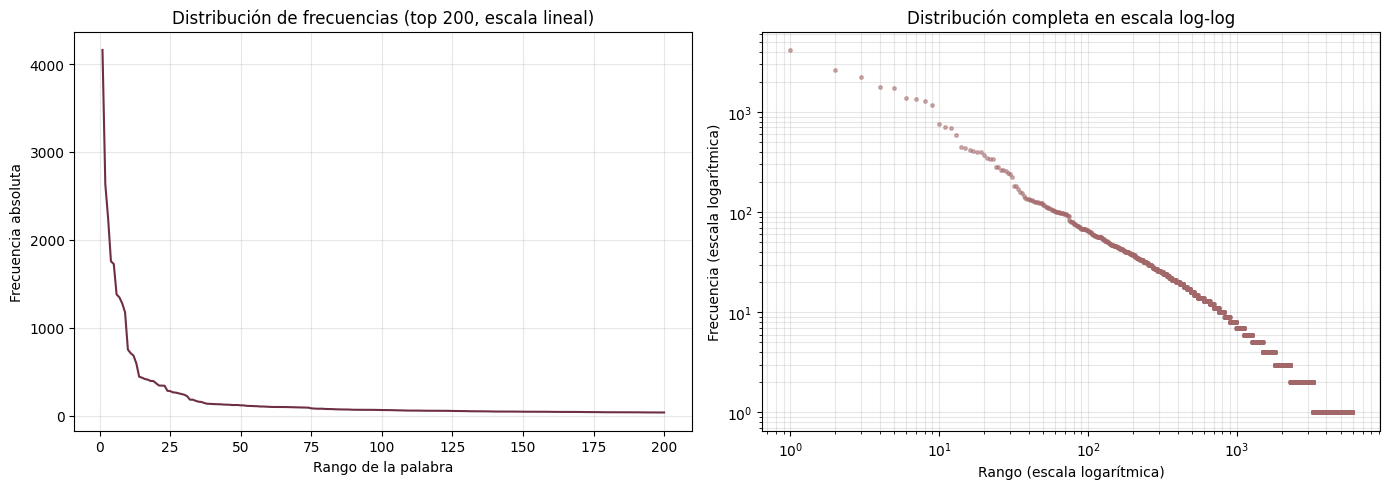

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala lineal: top 200 palabras
top200 = freq_pd.head(200)
axes[0].plot(top200["rango"], top200["count"],
             color="#6D2E46", linewidth=1.5)
axes[0].set_xlabel("Rango de la palabra")
axes[0].set_ylabel("Frecuencia absoluta")
axes[0].set_title("Distribución de frecuencias (top 200, escala lineal)")
axes[0].grid(True, alpha=0.3)

# Escala log-log: todo el vocabulario
axes[1].loglog(freq_pd["rango"], freq_pd["count"],
               "o", color="#A26769", markersize=2.5, alpha=0.5)
axes[1].set_xlabel("Rango (escala logarítmica)")
axes[1].set_ylabel("Frecuencia (escala logarítmica)")
axes[1].set_title("Distribución completa en escala log-log")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

### Pregunta conceptual 6.1

**Pregunta a:** Compare los dos gráficos. ¿Qué información transmite cada uno
mejor que el otro? ¿Por qué la escala log-log es preferida para estudiar
distribuciones zipfianas?

**Pregunta b:** Observando el gráfico log-log, ¿le parece que los puntos están
alineados sobre una recta? Si hay desviaciones, ¿en qué partes del gráfico
ocurren? (¿al inicio, al final, en el medio?).

**Respuestas a la pregunta 6.1**

**Respuesta a:** el segundo grafico la distribucion de los datos en escala log log muestra mas una pendiente negativa en cambio el otro no.

porque esta escala nos permite comparar con la distribucion normal

**Respuesta b:** si parece alineados sobre una recta, las desviaciones ocurren al inicio y al final

### Tarea 6.2: Estimación del exponente $\alpha$ por regresión lineal

Para estimar formalmente el exponente de Zipf, ajustaremos una recta a los datos
en escala log-log.

In [ ]:
# Tomar logaritmo en base 10 de rango y frecuencia
log_rango = np.log10(freq_pd["rango"].values)
log_freq = np.log10(freq_pd["count"].values)

# Regresión lineal: log f = log k - alpha * log r
# La pendiente es -alpha
slope, intercept, r_value, p_value, std_err = stats.linregress(log_rango, log_freq)

alpha = -slope
k = 10 ** intercept

print("Resultados del ajuste de Zipf por mínimos cuadrados:")
print(f"  Pendiente estimada:    {slope:.4f}")
print(f"  Exponente alpha:       {alpha:.4f}")
print(f"  Constante k:           {k:.4f}")
print(f"  Coeficiente R^2:       {r_value**2:.4f}")
print(f"  Error estándar:        {std_err:.4f}")
print(f"  Valor p:               {p_value:.4e}")

Resultados del ajuste de Zipf por mínimos cuadrados:
  Pendiente estimada:    -1.1539
  Exponente alpha:       1.1539
  Constante k:           18078.1247
  Coeficiente R^2:       0.9731
  Error estándar:        0.0025
  Valor p:               0.0000e+00


### Tarea 6.3: Visualización con la recta ajustada

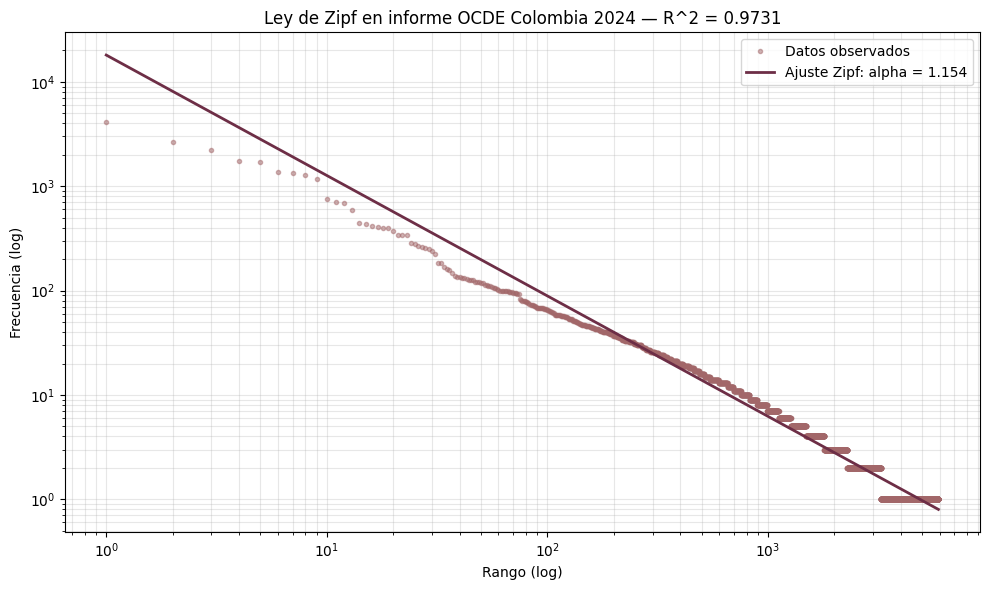

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Datos observados
ax.loglog(freq_pd["rango"], freq_pd["count"],
          "o", color="#A26769", markersize=3, alpha=0.5,
          label="Datos observados")

# Recta ajustada
rangos_aj = np.array([1, freq_pd["rango"].max()])
freq_aj = k / rangos_aj ** alpha
ax.loglog(rangos_aj, freq_aj, "-", color="#6D2E46", linewidth=2,
          label=f"Ajuste Zipf: alpha = {alpha:.3f}")

ax.set_xlabel("Rango (log)")
ax.set_ylabel("Frecuencia (log)")
ax.set_title(f"Ley de Zipf en informe OCDE Colombia 2024 — R^2 = {r_value**2:.4f}")
ax.grid(True, alpha=0.3, which="both")
ax.legend()

plt.tight_layout()
plt.show()

### Pregunta conceptual 6.2

**Pregunta a:** El valor empírico de $\alpha$ que obtuvo, ¿cómo se compara con
$\alpha = 1$ (Zipf clásico)? Calcule la diferencia y razone si es estadísticamente
significativa, dado el error estándar.

**Pregunta b:** El coeficiente de determinación $R^2$ mide qué fracción de la
varianza en $\log f$ es explicada por $\log r$. Interprete el valor obtenido.
¿Qué implicaría un $R^2 = 1$? ¿Y un $R^2 = 0$?

**Pregunta c:** Mire el gráfico cuidadosamente. ¿Hay una zona donde los puntos se
desvían sistemáticamente de la recta? Si la hay, propóngale una explicación
lingüística o estadística a esa desviación. Pista: piense en las frases hechas y
en las palabras únicas.

**Pregunta d:** Si en lugar de un informe técnico hubiéramos analizado un corpus
de tweets en español, ¿esperaría obtener un valor de $\alpha$ mayor o menor?
Justifique con un argumento lingüístico.

**Respuestas a la pregunta 6.2**

**Respuesta a:** si es estadisticamente significativo ya que la diferencia entre los alphas es de 0.1539 y ese valor es mucho mayor que el error estandar de 0.0025

**Respuesta b:** el valor optenido fue de 0.9731 esto significa que el 97.31% de la varianza en el logaritmo  de las frecuencias de las palabras puede ser explicado por el logaritmo de sus rangos, es un valor alto lo que significa que el modelo se ajuste bien a los datos

**Respuesta c:**
 a inicio y al final, esto se debe que al inicio hay palabras de muy alt rango como lo son palabras como articulos preposiciones que son bastantes frecuentes, y al final porque son palabras de poco rango como lo son los hapax

**Respuesta d:**  al ser tweets son frases cortas lo que implica mas diversidad lexica y menos concentracion de frecuencias en palabras relevantes.

---

## Bloque 7. Síntesis: reporte de hallazgos

### Marco conceptual

El producto final de un análisis estadístico no son las tablas y gráficos por sí
mismos, sino las **conclusiones** que se derivan de ellos. Un buen reporte de
hallazgos:

1. Cita números específicos (no afirmaciones genéricas).
2. Conecta la evidencia con conceptos teóricos.
3. Aporta interpretación propia, no solo descripción.
4. Reconoce limitaciones del análisis.

### Tarea 7.1: Visualización de cierre

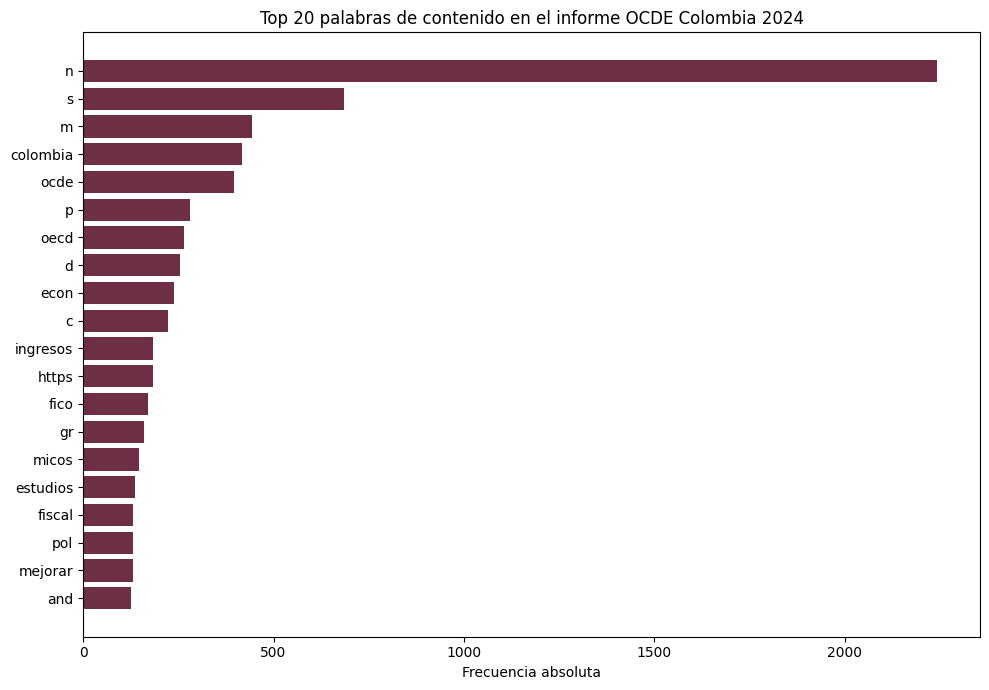

In [ ]:
# Top 20 palabras significativas para el reporte
top20 = frecuencias_f.limit(20).toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["palabra"][::-1], top20["count"][::-1], color="#6D2E46")
ax.set_xlabel("Frecuencia absoluta")
ax.set_title("Top 20 palabras de contenido en el informe OCDE Colombia 2024")
plt.tight_layout()
plt.show()

### Tarea 7.2: Reporte de cinco hallazgos

Redacte cinco hallazgos sobre el informe OCDE Colombia 2024 derivados de su
análisis estadístico. Cada hallazgo debe cumplir con la siguiente rúbrica:

- **Componente cuantitativo:** cite al menos un número específico de su análisis
  (no escriba "muchas palabras", sino "1.247 hapax").
- **Componente conceptual:** mencione explícitamente el concepto del taller que
  está usando (TTR, Zipf, hapax, cobertura, etc.).
- **Componente interpretativo:** ofrezca una lectura propia. ¿Qué le dice el
  número sobre el documento? ¿Qué implicaría para un análisis posterior?

Cada hallazgo debe tener entre tres y cinco líneas.

**Ejemplo de hallazgo bien construido (no copiar):**

> *El informe presenta un TTR de 0.0312 calculado sobre 142.351 tokens y un
> vocabulario de 4.441 tipos. Este valor es consistente con el rango esperado
> para documentos técnicos (0.02 - 0.05) y notablemente más bajo que el de un
> corpus literario, lo cual refleja la repetición intencional de terminología
> económica especializada propia del género del informe institucional.*

**Mis cinco hallazgos sobre el informe OCDE Colombia 2024**

**Hallazgo 1:** la TTR de nuestro corpus con el metodo regextokenizar se redujo a 0.0973 enos a la de tokenizacion basica, esto implica una medida mas precisa al limpiar teniendo en cuenta puntuacion y signos especiales.

**Hallazgo 2:** el corpux contiene 2699 hapax legomena, representa el 45.8% del vocabulario total despues de explicar stop words, significa que una parte importante del vocabulario tiene una frecuencia baja

**Hallazgo 3:** La cobertura del vocabulario en el corpus muestra una distribución de cola pesada: se necesita un 1.08% del vocabulario para cubrir el 50% de los tokens, mientras que el 51.74% del vocabulario es necesario para cubrir el 95% de los tokens. Conceptualmente, esta asimetría es un patrón esperado en textos de lenguaje natural distribución de Zipf, indicando que un pequeño conjunto de palabras muy frecuentes domina el texto, mientras que una gran cantidad de palabras raras incluidos los hapax contribuyen poco a la masa total del contenido pero sí a la diversidad del vocabulario.

**Hallazgo 4:**la ley de zipf se ajusta muy bien al corpus con un alpha de 1.1539 y un R^2 de 0.9731 este valor es estadisticamente significativo mayor que el alpha = 1 clasico

**Hallazgo 5:** el filtrado de stop words incremento drasticamente la capacidad de identificar el contenido tematico del documento

### Pregunta conceptual final

**Reflexión metodológica:** Identifique al menos dos limitaciones de este análisis.
Por ejemplo: ¿qué efecto pudo tener la limpieza imperfecta del PDF? ¿qué
información se pierde al hacer tokenización a nivel de palabra y no de oración?
¿qué sesgos puede tener la lista de stop words por defecto? ¿cómo afectaría a sus
resultados haber elegido un rango de páginas distinto?

Esta reflexión es importante: identificar limitaciones es señal de madurez
analítica.

**Reflexión metodológica final**

Limitación 1: Problemas con la extracción del PDF. Aunque limpiamos el texto, es muy difícil eliminar *todo* el ruido de un PDF. Pueden quedar caracteres raros, palabras mal cortadas o información de encabezados/pies de página. Esto puede hacer que contemos palabras que no son reales o que una misma palabra se vea como dos diferentes, inflando nuestro vocabulario.

Limitación 2: Análisis sin contexto de oración. Al tokenizar solo palabras, perdemos la información de cómo se conectan en una frase. No sabemos si una palabra es un verbo o un sustantivo, o si está negada. Esto limita mucho lo que podemos analizar, por ejemplo, no podemos hacer análisis de sentimiento o entender el significado más profundo de las oraciones.

---

## Verificación antes de entregar

Antes de subir su trabajo a GitHub, verifique:

- [ ] Ejecuté `Restart & Run All` y todas las celdas corren sin errores.
- [ ] Respondí todas las preguntas conceptuales (no quedó ningún *(escriba aquí)*).
- [ ] Los cinco hallazgos cumplen con los tres componentes (cuantitativo,
  conceptual, interpretativo).
- [ ] Reflexioné sobre las limitaciones del análisis.
- [ ] El nombre del archivo es `TallerNLP_Sesion25_PrimerNombre_PrimerApellido.ipynb`.
- [ ] El repositorio incluye un `README.md` con mi nombre completo y un párrafo
  de tres líneas resumiendo el taller.

---

*Profesora: Luz Adriana Gutiérrez Rodríguez*  
*Estadística — Universidad Santo Tomás*  
*Semestre 2026-I*